In [ ]:
!pip install networkx
!pip install matplotlib

In [ ]:
import sys
import networkx as nx
import matplotlib.pyplot as plt
import numpy

assigning variable and some nodes

## > Add blockquote

> Add blockquote
karate_club_graph already have some labled nodes




In [ ]:
zxc_graph = nx.karate_club_graph()
Mr_S= 0
Jay_A= 33
club_labels = nx.get_node_attributes(zxc_graph, 'club')
print({key:club_labels[key] for key in range(0,33)})

{0: 'Mr. Hi', 1: 'Mr. Hi', 2: 'Mr. Hi', 3: 'Mr. Hi', 4: 'Mr. Hi', 5: 'Mr. Hi', 6: 'Mr. Hi', 7: 'Mr. Hi', 8: 'Mr. Hi', 9: 'Officer', 10: 'Mr. Hi', 11: 'Mr. Hi', 12: 'Mr. Hi', 13: 'Mr. Hi', 14: 'Officer', 15: 'Officer', 16: 'Mr. Hi', 17: 'Mr. Hi', 18: 'Officer', 19: 'Mr. Hi', 20: 'Officer', 21: 'Mr. Hi', 22: 'Officer', 23: 'Officer', 24: 'Officer', 25: 'Officer', 26: 'Officer', 27: 'Officer', 28: 'Officer', 29: 'Officer', 30: 'Officer', 31: 'Officer', 32: 'Officer'}


graph to matrices



---



In [ ]:
A = nx.convert_matrix.to_numpy_array(zxc_graph)
A

array([[0., 4., 5., ..., 2., 0., 0.],
       [4., 0., 6., ..., 0., 0., 0.],
       [5., 6., 0., ..., 0., 2., 0.],
       ...,
       [2., 0., 0., ..., 0., 4., 4.],
       [0., 0., 2., ..., 4., 0., 5.],
       [0., 0., 0., ..., 4., 5., 0.]])

layout

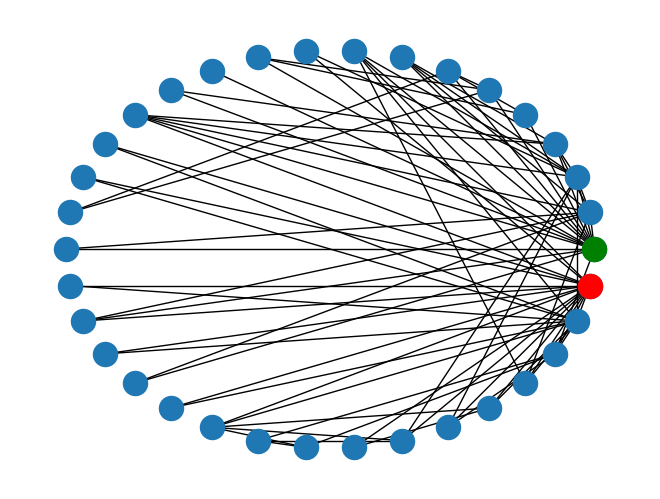

In [ ]:
circ_pos= nx.circular_layout(zxc_graph)
nx.draw(zxc_graph, circ_pos)
nx.draw_networkx_nodes(zxc_graph, circ_pos, nodelist=[Mr_S], node_color= 'g', alpha=1)
nx.draw_networkx_nodes(zxc_graph, circ_pos, nodelist=[Jay_A], node_color= 'r', alpha=1)

first task to analysis network is to identify density
density is the comparision of no.of edges and the possible number of edges if d= 1 every possible edge exist in a network d=0 not connection among the nodes

In [ ]:
density = nx.density(zxc_graph)
print ("the edge density is " + str(density))

the edge density is 0.13903743315508021


second degree how many edges each node has
high centrality essential role in a network

In [ ]:
degree = zxc_graph.degree()
degree_list=[]

for (n,d) in degree:
  degree_list.append(d)
av_degree = sum(degree_list)/ len(degree_list)
print("the average degree is " + str(av_degree))

the average degree is 4.588235294117647


graphical output

Text(0.5, 1.0, 'Karate_club: Node Degree')

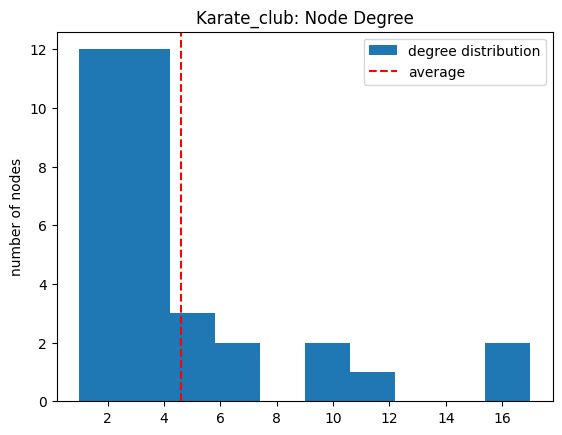

In [ ]:
plt.hist(degree_list, label= 'degree distribution')
plt.axvline(av_degree, color='r', linestyle='dashed', label='average')
plt.legend()
plt.ylabel('number of nodes')
plt.title('Karate_club: Node Degree')

clustering coffiecients (group inside a network)
measurement of people you may be interested to connected with
if CC is low then there is  structure hole in network that is there is region in the network with there are missing linkages that would have otherwise been predicted that a node is situated on the cluster's periphery is usually indicate by the fact that it has this label it has been hypothesized that people who are located in structured holes in the network are more likely to have creative ideas they are ait the edge if a densely packed cluster of nodes which means that there are wider idea other than cluster

In [ ]:
local_clustering_coffiecient = nx.algorithms.cluster.clustering(zxc_graph)
av_local_clustering_coffiecient= sum(local_clustering_coffiecient.values())/ len(local_clustering_coffiecient)
print('the average is ' + str(av_local_clustering_coffiecient))

the average is 0.5706384782076823


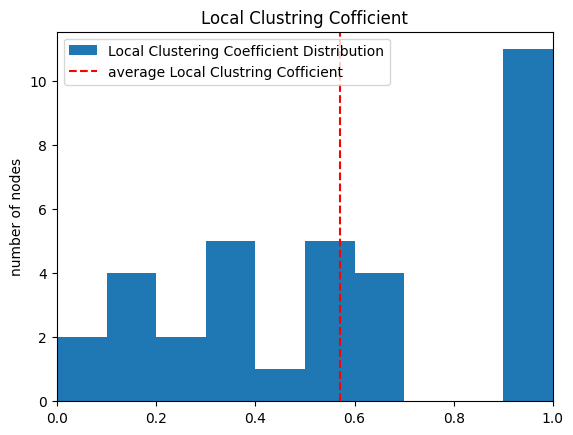

In [ ]:
import numpy as np
local_clustering_coffiecient = nx.algorithms.cluster.clustering(zxc_graph)
av_local_clustering_coffiecient= sum(local_clustering_coffiecient.values())/len(local_clustering_coffiecient)
plt.hist(local_clustering_coffiecient.values(),label='Local Clustering Coefficient Distribution')

plt.axvline(av_local_clustering_coffiecient, color='r', linestyle='dashed', label='average Local Clustring Cofficient')
plt.legend()
plt.ylabel('number of nodes')
plt.xlim(0.0, 1.0)
plt.title('Local Clustring Cofficient')
plt.show()

community identification with networks may be approached in that how many community is in Mr_S side and Jay_A
modularity gdegree to which nodes in a network are conneccted to nodes of the same type is referred to as a modularity of the network because algorithm phele se hi networkx me present hai

In [ ]:
from networkx.algorithms.community.modularity_max import greedy_modularity_communities
c = list(greedy_modularity_communities(zxc_graph))
print(len(c))

3


In [ ]:
community_0 = sorted(c[0])
community_1 = sorted(c[1])
community_2 = sorted(c[2])
print(community_0)
print(community_1)
print(community_2)




[8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
[1, 2, 3, 7, 9, 12, 13, 17, 21]
[0, 4, 5, 6, 10, 11, 16, 19]


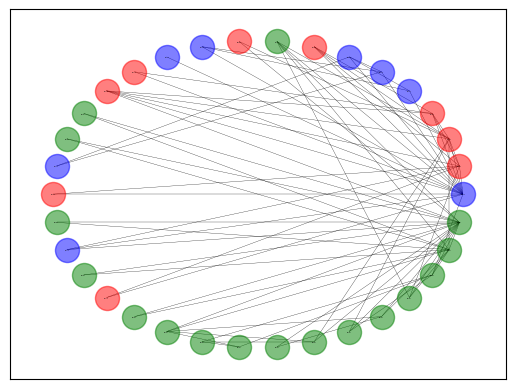

In [ ]:
nx.draw_networkx_nodes(zxc_graph, circ_pos, nodelist=community_0, node_color= 'g', alpha=0.5)
nx.draw_networkx_nodes(zxc_graph, circ_pos, nodelist=community_1, node_color= 'r', alpha=0.5)
nx.draw_networkx_nodes(zxc_graph, circ_pos, nodelist=community_2, node_color= 'b', alpha=0.5)

nx.draw_networkx_edges(zxc_graph, circ_pos, width = 0.2)
nx.draw_networkx_labels(zxc_graph, circ_pos, club_labels, font_size = 0.09)
plt.show()

between

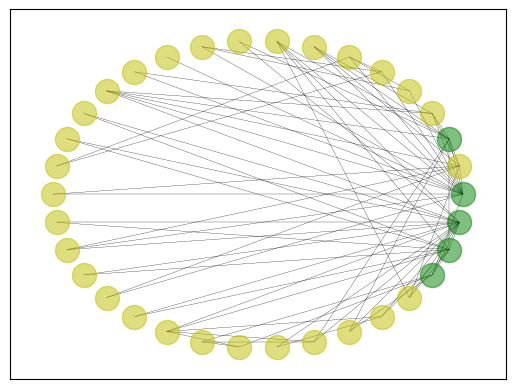

In [ ]:
from networkx import betweenness_centrality
betweenness_dict = betweenness_centrality(zxc_graph)
threshold = 0.1
high_bc_nodes = [node for node, score in betweenness_dict.items() if score >= threshold]
low_bc_nodes = [node for node, score in betweenness_dict.items() if score <= threshold]
medium_bc_nodes = [node for node, score in betweenness_dict.items() if score == threshold]
nx.draw_networkx_nodes(zxc_graph, circ_pos, nodelist= high_bc_nodes, node_color= 'g', alpha= 0.5)
nx.draw_networkx_nodes(zxc_graph, circ_pos, nodelist= low_bc_nodes, node_color= 'y', alpha= 0.5)
nx.draw_networkx_nodes(zxc_graph, circ_pos, nodelist= medium_bc_nodes, node_color= 'b', alpha= 0.5)
nx.draw_networkx_edges(zxc_graph, circ_pos, width = 0.2)

plt.show()


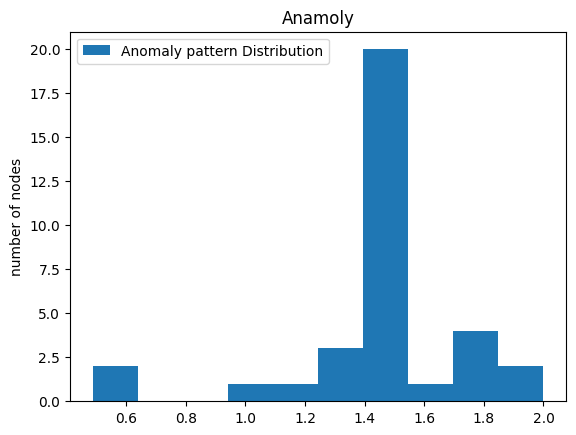

In [ ]:
degree_dict = dict(zxc_graph.degree())
def normalize(d):
    vals = list(d.values())
    min_v, max_v = min(vals), max(vals)
    return {k: (v - min_v) / (max_v - min_v + 1e-9) for k, v in d.items()}

norm_deg = normalize(degree_dict)
norm_clust = normalize(local_clustering_coffiecient)
norm_bet = normalize(betweenness_dict)
alpha, beta, gamma = 1.0, 0.5, 0.5
anomaly_scores = {
    n: alpha*(1 - norm_deg[n]) + beta*(1 - norm_clust[n]) + gamma*(1 - norm_bet[n])
    for n in zxc_graph.nodes()
}
plt.hist(anomaly_scores.values(),label='Anomaly pattern Distribution')


plt.legend()
plt.ylabel('number of nodes')

plt.title('Anamoly')
plt.show()

In [ ]:
path = nx.dijkstra_path(zxc_graph, source=0, target=23)
length = nx.dijkstra_path_length(zxc_graph, source=0, target=23)

print(path)
print(length)

[0, 19, 33, 23]
7
